# What drives the price of a car? Analysis

Applying the CRISP-DM framework to understand the key drivers of used car prices.

## 1. Load and Explore Data

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null 

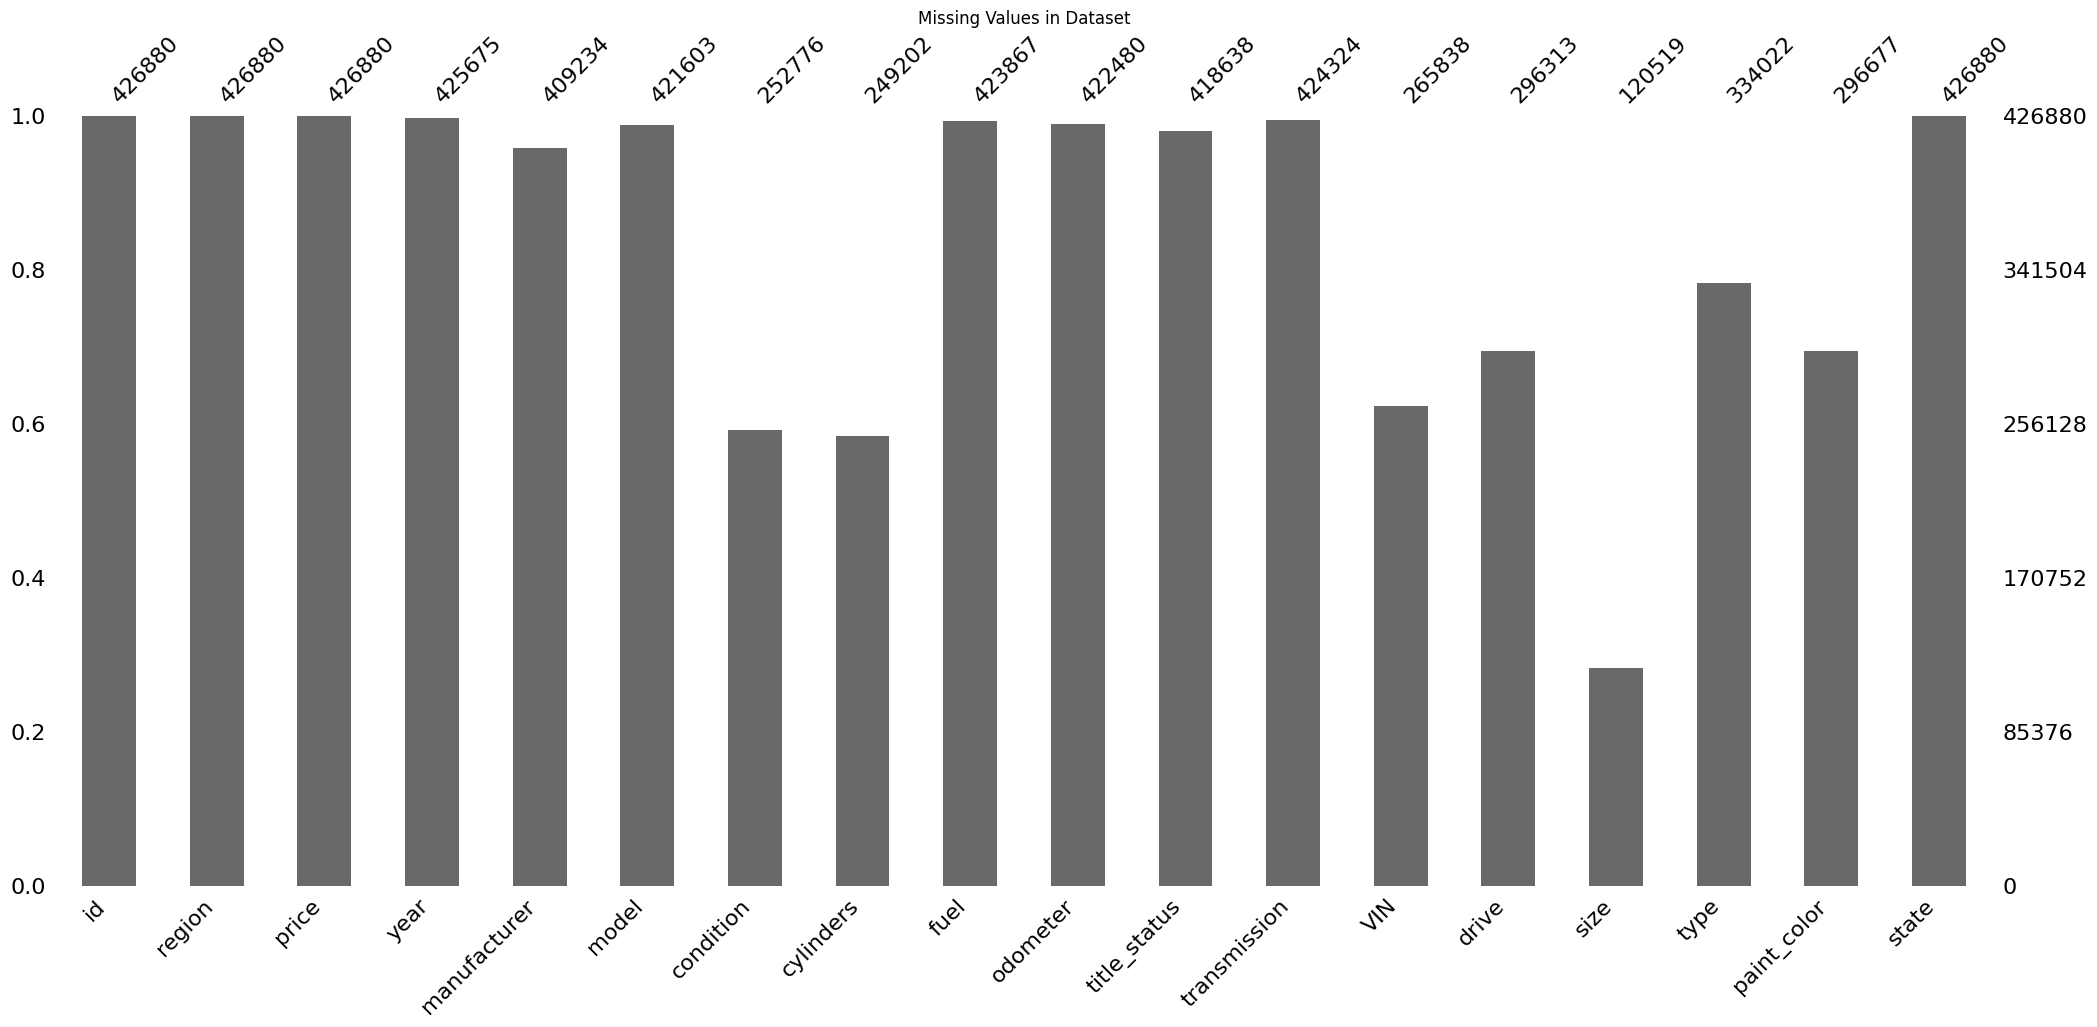

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [8]:
!pip install missingno

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import missingno as msno  # Library for missing values visualization

# Load the dataset

file_path = "/Users/anumita/Downloads/practical_application_II_starter/data/vehicles.csv"
df = pd.read_csv(file_path)
df.head()

# Display dataset structure
print("Dataset Overview:")
print(df.info())

# Check missing values
print("\nMissing Values Per Column:")
print(df.isnull().sum())

# Visualize missing values
msno.bar(df)
plt.title("Missing Values in Dataset")
plt.show()

# Display first five rows
df.head()

## 2. Data Cleaning & Preparation

In [9]:
# Drop unnecessary columns
df_cleaned = df.drop(columns=['id', 'VIN'])
# Handle missing values
df_cleaned = df_cleaned.dropna(subset=['price', 'year'])
categorical_columns = ['manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color']
for col in categorical_columns:
    df_cleaned[col] = df_cleaned[col].fillna('Unknown')

df_cleaned['odometer'].fillna(df_cleaned['odometer'].median(),inplace=True)
df_cleaned['year'] = df_cleaned['year'].astype(int)
df_cleaned['car_age'] = 2025 - df_cleaned['year']
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 425675 entries, 27 to 426879
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        425675 non-null  object 
 1   price         425675 non-null  int64  
 2   year          425675 non-null  int64  
 3   manufacturer  425675 non-null  object 
 4   model         425675 non-null  object 
 5   condition     425675 non-null  object 
 6   cylinders     425675 non-null  object 
 7   fuel          425675 non-null  object 
 8   odometer      425675 non-null  float64
 9   title_status  425675 non-null  object 
 10  transmission  425675 non-null  object 
 11  drive         425675 non-null  object 
 12  size          425675 non-null  object 
 13  type          425675 non-null  object 
 14  paint_color   425675 non-null  object 
 15  state         425675 non-null  object 
 16  car_age       425675 non-null  int64  
dtypes: float64(1), int64(3), object(13)
memory usag

## 3. Exploratory Data Analysis (EDA)

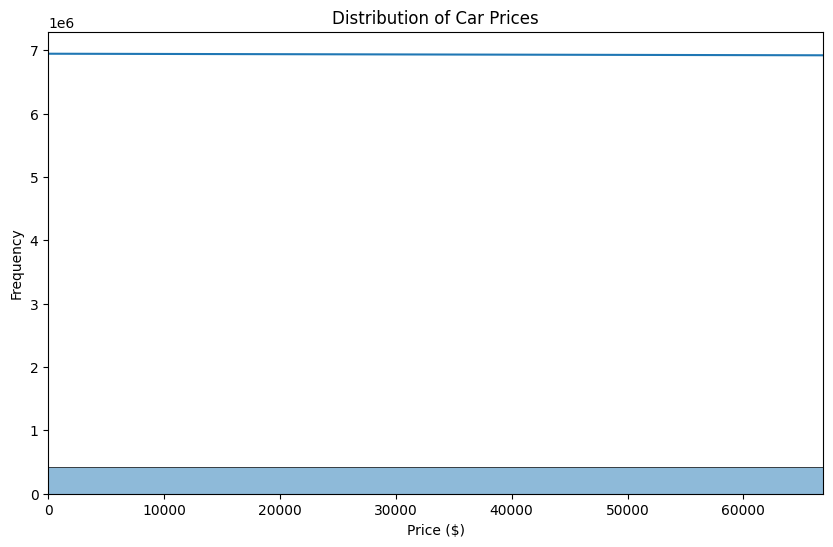

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['price'], bins=100, kde=True)
plt.xlim(0, df_cleaned['price'].quantile(0.99))
plt.title("Distribution of Car Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

## 4. Data Preprocessing

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV

file_path = "/Users/anumita/Downloads/practical_application_II_starter/data/vehicles.csv"
df= pd.read_csv(file_path)
df.head()

# Data Cleaning
df_cleaned = df.copy() #copy for avoiding modifying dataset

# Drop unnecessary columns
df_cleaned =df_cleaned.drop(columns=['id','VIN'], errors='ignore')

# Drop rows with missing $ or year
df_cleaned=df_cleaned.dropna(subset=['price','year'])

# Missing value with "Unknown"
categorical_columns = ['manufacturer','fuel', 'transmission','drive','type','paint_color']
for col in categorical_columns:
    df_cleaned[col]= df_cleaned[col].fillna('Unknown')

# Missing od values with median
df_cleaned['odometer'].fillna(df_cleaned['odometer'].median(),inplace=True)

#'Year' column to integer
df_cleaned['year'] =df_cleaned['year'].astype(int)

# New column for car age
df_cleaned['car_age']=2025 - df_cleaned['year']  # Assuming the current year is 2025

# Verify
df_cleaned.info()
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 425675 entries, 27 to 426879
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        425675 non-null  object 
 1   price         425675 non-null  int64  
 2   year          425675 non-null  int64  
 3   manufacturer  425675 non-null  object 
 4   model         420466 non-null  object 
 5   condition     252766 non-null  object 
 6   cylinders     248084 non-null  object 
 7   fuel          425675 non-null  object 
 8   odometer      425675 non-null  float64
 9   title_status  417745 non-null  object 
 10  transmission  425675 non-null  object 
 11  drive         425675 non-null  object 
 12  size          120519 non-null  object 
 13  type          425675 non-null  object 
 14  paint_color   425675 non-null  object 
 15  state         425675 non-null  object 
 16  car_age       425675 non-null  int64  
dtypes: float64(1), int64(3), object(13)
memory usag

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,car_age
27,auburn,33590,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,Unknown,NaN,pickup,white,al,11
28,auburn,22590,2010,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,Unknown,NaN,pickup,blue,al,15
29,auburn,39590,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,Unknown,NaN,pickup,red,al,5
30,auburn,30990,2017,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,Unknown,NaN,pickup,red,al,8
31,auburn,15000,2013,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,full-size,truck,black,al,12


## 5. Model Training & Evaluation

In [ ]:
# Import
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Feature set (X) and target variable (y)
X = df_cleaned[['car_age', 'odometer', 'manufacturer', 'fuel', 'transmission', 'drive', 'type', 'paint_color']]
y =df_cleaned['price']

# Train-test split
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.2, random_state=42)

# Categorical and numerical features
categorical_features=['manufacturer', 'fuel', 'transmission', 'drive', 'type', 'paint_color']
numerical_features = ['car_age','odometer']

# Preprocessing
preprocessor =ColumnTransformer(transformers=[
    ('num',StandardScaler(), numerical_features), 
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False),categorical_features)  
])

# Fit and transform
X_train_preprocessed= preprocessor.fit_transform(X_train)
X_test_preprocessed=preprocessor.transform(X_test)

# Confirm after preprocessing
print("Training Data Shape:",X_train_preprocessed.shape)
print("Testing Data Shape:", X_test_preprocessed.shape)

# Initialize
lr = LinearRegression()
rf=RandomForestRegressor(n_estimators=100, random_state=42)
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# Train
lr.fit(X_train_preprocessed, y_train)
rf.fit(X_train_preprocessed,y_train)
gbr.fit(X_train_preprocessed, y_train)

# Make predictions
y_pred_lr= lr.predict(X_test_preprocessed)
y_pred_rf =rf.predict(X_test_preprocessed)
y_pred_gbr = gbr.predict(X_test_preprocessed)

# Evaluate
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse =np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return pd.DataFrame([[model_name,mae, rmse, r2]], columns=['Model','MAE','RMSE', 'R² Score'])

# Collect
results_df = pd.concat([
    evaluate_model(y_test,y_pred_lr, "Linear Regression"),
    evaluate_model(y_test, y_pred_rf, "Random Forest"),
    evaluate_model(y_test,y_pred_gbr, "Gradient Boosting")
], ignore_index=True)

# Display
import ace_tools as tools
tools.display_dataframe_to_user(name="Model Evaluation Results", dataframe=results_df)


Training Data Shape: (340540, 86)
Testing Data Shape: (85135, 86)
